# Training Demo 01: Mouse Embryogenesis Subset Training

This notebook shows how to train **Navigo** on a sampled mouse embryogenesis subset using the standard repository training script, then inspect optimization and alignment metrics from the run.

In this notebook you will:
1. Sample **10,000 cells** across **10 training time points** from the full embryogenesis atlas.
2. Inspect the sampled subset composition across developmental days.
3. Train Navigo end to end with `submission/main_navigo.py` on **GPU**.
4. Review **loss curves** and **round-wise EMD metrics** collected during training.


Import required packages and set deterministic seeds.

In [1]:
import json
import os
os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba_cache')
import random
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy import sparse

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Seed set to {SEED}')


Seed set to 42


Define shared helpers for path resolution and dense conversion.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError('Could not locate repository root containing docs/tutorials and the navigo package.')


def to_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def parse_training_log(log_path: Path) -> pd.DataFrame:
    if not log_path.exists():
        return pd.DataFrame()

    records = []
    text = log_path.read_text(encoding='utf-8', errors='ignore').replace('\r', '\n')
    for line in text.splitlines():
        if 'all_loss:' not in line:
            continue
        pairs = re.findall(r'([A-Za-z0-9_]+):\s*([0-9.]+)', line)
        if not pairs:
            continue
        row = {key: float(value) for key, value in pairs}
        row['train_step'] = len(records) + 1
        records.append(row)
    return pd.DataFrame(records)


def summarize_round_scores(score_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    round_rows = []
    final_detail_df = pd.DataFrame()

    for score_path in sorted(score_dir.glob('score_*.json')):
        round_idx = int(score_path.stem.split('_')[-1]) + 1
        score_payload = json.loads(score_path.read_text())
        detail_rows = []
        for time_str, metrics in sorted(score_payload.items(), key=lambda item: float(item[0])):
            baseline = float(metrics['baseline'])
            prediction = float(metrics['prediction'])
            detail_rows.append(
                {
                    'round': round_idx,
                    'time': float(time_str),
                    'prediction_emd': prediction,
                    'baseline_emd': baseline,
                    'improvement': baseline - prediction,
                    'relative_improvement': (baseline - prediction) / baseline if baseline > 0 else 0.0,
                }
            )
        detail_df = pd.DataFrame(detail_rows).sort_values('time').reset_index(drop=True)
        if detail_df.empty:
            continue
        round_rows.append(
            {
                'round': round_idx,
                'mean_prediction_emd': detail_df['prediction_emd'].mean(),
                'mean_baseline_emd': detail_df['baseline_emd'].mean(),
                'mean_improvement': detail_df['improvement'].mean(),
                'mean_relative_improvement': detail_df['relative_improvement'].mean(),
            }
        )
        final_detail_df = detail_df

    return pd.DataFrame(round_rows), final_detail_df


Set paths and runtime configuration for the training demo.

In [3]:
repo_root = find_repo_root(Path.cwd().resolve())
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'training_demo'
output_root = tutorials_root / 'outputs' / 'training_demo'

data_root = repo_root / 'data' / 'interpolation'
full_data = data_root / 'mouse_embryogenesis_aggregated_full_hvg_4000.h5ad'
subset_data = output_root / '00_subset' / 'mouse_embryogenesis_training_subset_10k_10tp.h5ad'
subset_summary = subset_data.with_suffix('.json')
subset_overview_png = output_root / '00_subset' / 'subset_sampling_overview.png'

REUSE_EXISTING = True
RUN_SUBSET_SAMPLING = True
RUN_TRAINING = True
SUBSET_TOTAL_CELLS = 10000
SUBSET_NUM_TIMEPOINTS = 10
TRAIN_ROUNDS = 3
TRAIN_STEPS = 20
TRAIN_BATCH_SIZE = 16
TRAIN_DEVICE = 'cuda'
TRAIN_TAG = f'gpu0_bs{TRAIN_BATCH_SIZE}_r{TRAIN_ROUNDS}_s{TRAIN_STEPS}_subset10k'

training_output_dir = output_root / f'01_training_run_{TRAIN_TAG}'
training_log_path = training_output_dir / 'training_stdout.log'
metrics_plot_png = output_root / '03_notebook_figures' / f'training_metrics_summary_{TRAIN_TAG}.png'

sample_script = repo_root / 'navigo' / 'training_demo_sample_training_subset.py'
train_script = repo_root / 'submission' / 'main_navigo.py'

output_root.mkdir(parents=True, exist_ok=True)
metrics_plot_png.parent.mkdir(parents=True, exist_ok=True)

pd.DataFrame(
    [
        {'item': 'Subset dataset', 'value': str(subset_data.relative_to(repo_root))},
        {'item': 'Training output dir', 'value': str(training_output_dir.relative_to(repo_root))},
        {'item': 'Training device', 'value': TRAIN_DEVICE},
        {'item': 'Rounds', 'value': TRAIN_ROUNDS},
        {'item': 'Train steps per round', 'value': TRAIN_STEPS},
        {'item': 'Batch size', 'value': TRAIN_BATCH_SIZE},
    ]
)


,item,value
0,Subset dataset,docs/tutorials/outputs/training_demo/00_subset...
1,Training output dir,docs/tutorials/outputs/training_demo/01_traini...
2,Training device,cuda
3,Rounds,3
4,Train steps per round,20
5,Batch size,16


## Step 1: Sample a 10k-cell, 10-timepoint training subset

In [4]:
if RUN_SUBSET_SAMPLING:
    if REUSE_EXISTING and subset_data.exists() and subset_summary.exists():
        print('Reusing existing sampled subset.')
    else:
        sample_cmd = [
            sys.executable,
            str(sample_script),
            '--input-data', str(full_data),
            '--output-data', str(subset_data),
            '--total-cells', str(SUBSET_TOTAL_CELLS),
            '--num-timepoints', str(SUBSET_NUM_TIMEPOINTS),
            '--seed', str(SEED),
            '--overwrite',
        ]
        subprocess.run(sample_cmd, check=True, cwd=repo_root)

subset_info = json.loads(subset_summary.read_text())
source_dataset_display = subset_info['source_dataset']
try:
    source_dataset_display = str(Path(source_dataset_display).relative_to(repo_root))
except Exception:
    pass

pd.DataFrame(
    [
        {'item': 'Source dataset', 'value': source_dataset_display},
        {'item': 'Total sampled cells', 'value': subset_info['total_cells']},
        {'item': 'Training time points', 'value': subset_info['num_timepoints']},
        {'item': 'Sampling seed', 'value': subset_info['seed']},
    ]
)


Reusing existing sampled subset.


,item,value
0,Source dataset,data/interpolation/mouse_embryogenesis_aggrega...
1,Total sampled cells,10000
2,Training time points,10
3,Sampling seed,42


## Step 2: Inspect the sampled subset composition

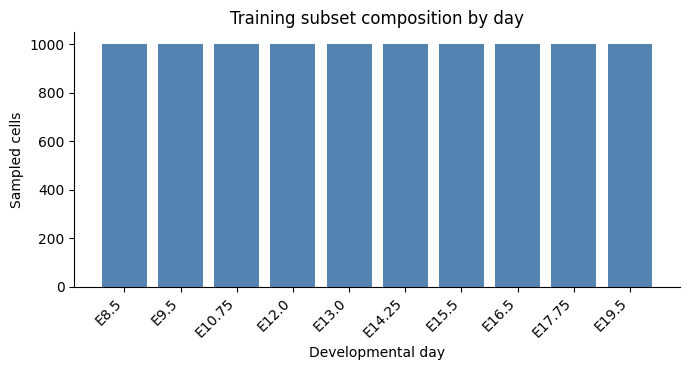

,day,time,sampled_cells,available_cells
0,E8.5,0.0,1000,28462
1,E9.5,4.0,1000,18014
2,E10.75,9.0,1000,10017
3,E12.0,14.0,1000,10120
4,E13.0,18.0,1000,18332
5,E14.25,23.0,1000,12268
6,E15.5,28.0,1000,12403
7,E16.5,32.0,1000,13655
8,E17.75,37.0,1000,12503
9,E19.5,44.0,1000,16525


In [5]:
subset_time_df = pd.DataFrame(subset_info['per_timepoint']).copy()
subset_time_df['day'] = subset_time_df['day'].astype(str)
subset_time_df['time'] = subset_time_df['time'].astype(float)

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.bar(subset_time_df['day'], subset_time_df['sampled_cells'], color='#4477aa', alpha=0.9)
ax.set_xlabel('Developmental day')
ax.set_ylabel('Sampled cells')
ax.set_title('Training subset composition by day')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(subset_overview_png, dpi=220, bbox_inches='tight')
plt.show()

subset_time_df[['day', 'time', 'sampled_cells', 'available_cells']]


## Step 3: Train Navigo with the repository training script
This uses the standard `submission/main_navigo.py` entrypoint on **GPU** with a compact tutorial schedule for the sampled subset.

In [6]:
train_env = dict(os.environ)
train_env['PYTHONPATH'] = str(repo_root) if not train_env.get('PYTHONPATH') else f"{repo_root}:{train_env['PYTHONPATH']}"

checkpoint_path = training_output_dir / f'checkpoint-{TRAIN_ROUNDS}.pth'
need_training_run = not (
    REUSE_EXISTING
    and checkpoint_path.exists()
    and training_log_path.exists()
    and len(list(training_output_dir.glob('score_*.json'))) == TRAIN_ROUNDS
)

if RUN_TRAINING:
    if need_training_run:
        training_output_dir.mkdir(parents=True, exist_ok=True)
        train_cmd = [
            sys.executable,
            str(train_script),
            '--input_data', str(subset_data),
            '--output_dir', str(training_output_dir),
            '--rounds', str(TRAIN_ROUNDS),
            '--train_steps', str(TRAIN_STEPS),
            '--batch_size', str(TRAIN_BATCH_SIZE),
            '--save_every', '1',
            '--device', TRAIN_DEVICE,
        ]
        proc = subprocess.run(
            train_cmd,
            check=True,
            cwd=repo_root,
            env=train_env,
            capture_output=True,
            text=True,
        )
        training_log_path.write_text((proc.stdout or '') + '\n' + (proc.stderr or ''), encoding='utf-8')
    else:
        print('Reusing existing training outputs.')

loss_df = parse_training_log(training_log_path)
checkpoint_df = pd.DataFrame({'checkpoint': [p.name for p in sorted(training_output_dir.glob('checkpoint-*.pth'))]})
print(f'Parsed {len(loss_df)} logged training steps.')
checkpoint_df


Reusing existing training outputs.
Parsed 60 logged training steps.


,checkpoint
0,checkpoint-1.pth
1,checkpoint-2.pth
2,checkpoint-3.pth


## Step 4: Review loss curves and alignment metrics

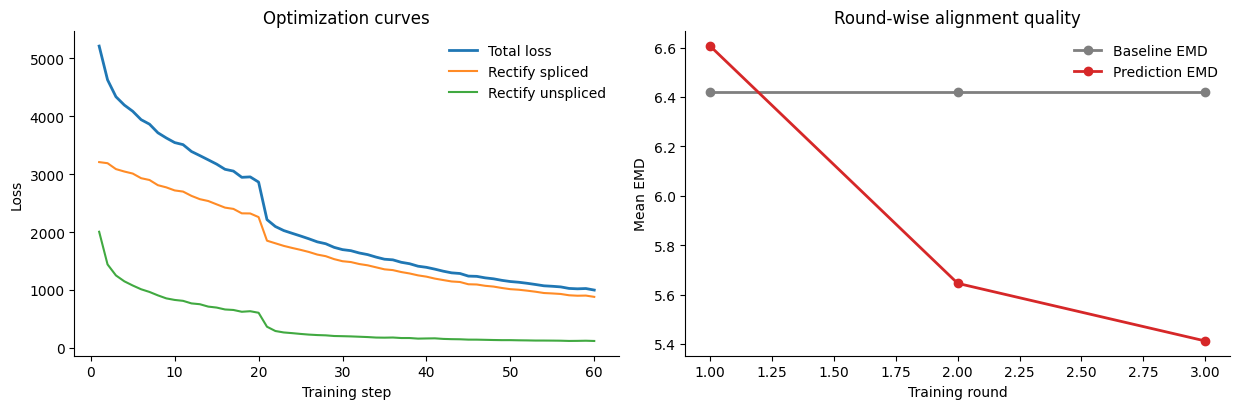

Round-wise summary:


,round,mean_prediction_emd,mean_baseline_emd,mean_improvement,mean_relative_improvement
0,1,6.605774,6.417941,-0.187833,-6.0%
1,2,5.645349,6.417941,0.772592,9.7%
2,3,5.412123,6.417941,1.005817,13.6%


Final round per-timepoint metrics:


,time,prediction_emd,baseline_emd,improvement,relative_improvement
0,0.0,6.152745,10.643696,4.490952,42.2%
1,4.0,4.497929,5.495137,0.997207,18.1%
2,9.0,5.327940,5.655322,0.327382,5.8%
3,14.0,4.509427,5.603030,1.093603,19.5%
4,18.0,4.843501,5.200809,0.357308,6.9%
5,23.0,6.419065,6.378068,-0.040997,-0.6%
6,28.0,5.081061,6.151720,1.070659,17.4%
7,32.0,4.895696,5.384466,0.488770,9.1%
8,37.0,6.981746,7.249220,0.267474,3.7%


In [7]:
if loss_df.empty:
    raise ValueError(f'No loss history could be parsed from {training_log_path}')

round_df, final_score_df = summarize_round_scores(training_output_dir)
if round_df.empty:
    raise ValueError(f'No round score files were found in {training_output_dir}')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].plot(loss_df['train_step'], loss_df['all_loss'], label='Total loss', color='#1f77b4', linewidth=2)
if 'all_loss_rectify_s' in loss_df.columns:
    axes[0].plot(loss_df['train_step'], loss_df['all_loss_rectify_s'], label='Rectify spliced', color='#ff7f0e', alpha=0.9)
if 'all_loss_rectify_u' in loss_df.columns:
    axes[0].plot(loss_df['train_step'], loss_df['all_loss_rectify_u'], label='Rectify unspliced', color='#2ca02c', alpha=0.9)
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Optimization curves')
axes[0].legend(frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(round_df['round'], round_df['mean_baseline_emd'], marker='o', label='Baseline EMD', color='#7f7f7f', linewidth=2)
axes[1].plot(round_df['round'], round_df['mean_prediction_emd'], marker='o', label='Prediction EMD', color='#d62728', linewidth=2)
axes[1].set_xlabel('Training round')
axes[1].set_ylabel('Mean EMD')
axes[1].set_title('Round-wise alignment quality')
axes[1].legend(frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(metrics_plot_png, dpi=220, bbox_inches='tight')
plt.show()

round_display_df = round_df.copy()
round_display_df['mean_relative_improvement'] = round_display_df['mean_relative_improvement'].map(lambda x: f'{x:.1%}')
print('Round-wise summary:')
display(round_display_df)

final_display_df = final_score_df[['time', 'prediction_emd', 'baseline_emd', 'improvement', 'relative_improvement']].copy()
final_display_df['relative_improvement'] = final_display_df['relative_improvement'].map(lambda x: f'{x:.1%}')
print('Final round per-timepoint metrics:')
final_display_df


## Notes

- The subset is only for tutorial-scale training and evaluation.
- The training run uses the same repository trainer as the full workflow.
- This notebook uses a compact schedule: `--rounds 3 --train_steps 20 --batch_size 16`.
- The round-wise EMD scores come from the alignment evaluation written by `submission/main_navigo.py` after each training round.
